In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from transformers import GPT2Tokenizer, GPT2LMHeadModel, AutoTokenizer, AutoModelForCausalLM
import numpy as np
import torch
from collections import defaultdict

In [ ]:
with open('./in.txt', 'r') as file:
    text_data = [line.strip() for line in file]

with open('./perplex.txt', 'r') as file:
    perplexity_data = [float(line.strip()) for line in file]

with open('./log.txt', 'r') as file:
    log_data = [float(line.strip()) for line in file]

with open('./v2.txt', 'r') as file:
    v2_data = [line.strip() for line in file]

with open('./2025-02-10-output.txt', 'r') as file:
    v3_data = [line.strip() for line in file]

with open('./2025-02-11-output.txt', 'r', encoding='utf-8') as file:
    v4_data = [line.strip() for line in file]

In [32]:
model = GPT2LMHeadModel.from_pretrained("gpt2")
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model.eval()

C:\Users\Makai\AppData\Roaming\Python\Python312\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D()
          (c_proj): Conv1D()
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D()
          (c_proj): Conv1D()
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [34]:
def calculate_perplexity(text):
    inputs = tokenizer.encode(text, return_tensors="pt")
    with torch.no_grad():
        outputs = model(inputs, labels=inputs)
        loss = outputs.loss
        perplexity = torch.exp(loss)
    return perplexity.item()

In [ ]:
class IcicleDiagramVisualizer:
    def __init__(self):
        self.tree = {}  # Main tree structure
        self.depths = defaultdict(list)  # Track words per depth

    def insert(self, sentence, perplexity):
        """ Insert a sentence into the tree structure with perplexity values. """
        perplexity = min(perplexity, 500)  # Clip perplexity at 300
        words = sentence.split()
        node = self.tree  # Start at root
        depth = 0

        for word in words:
            if word not in node:
                node[word] = {"children": {}, "perplexity": perplexity}
                self.depths[depth].append((word, node[word]))  # Store reference
            
            node = node[word]["children"]  # Move deeper into tree
            depth += 1

    def visualize(self):
        """ Draw a vertical icicle diagram where each column represents a depth level. """
        fig, ax = plt.subplots(figsize=(12, 6))
        max_depth = max(self.depths.keys()) + 1  # Total number of columns

        column_width = 1.0 / max_depth  # Set uniform column width
        
        # Collect all perplexity values for normalization
        all_perplexities = [node["perplexity"] for depth in self.depths.values() for _, node in depth]
        min_perp, max_perp = min(all_perplexities), max(all_perplexities)

        cmap = plt.cm.inferno  # Set colormap
        norm = plt.Normalize(vmin=min_perp, vmax=max_perp)  # Normalize perplexity values
        
        for depth, words in self.depths.items():
            num_words = len(words)
            row_height = 1.0 / num_words if num_words else 1.0  # Divide column evenly
            
            for i, (word, node) in enumerate(words):
                perplexity = node["perplexity"]  # Retrieve stored perplexity
                
                # Normalize perplexity between 0 and 1
                norm_perp = (perplexity - min_perp) / (max_perp - min_perp) if max_perp > min_perp else 0.5
                
                # Apply colormap
                color = cmap(norm(perplexity))

                rect = plt.Rectangle((depth * column_width, 1 - (i + 1) * row_height), 
                                    column_width, row_height, 
                                    facecolor=color)
                ax.add_patch(rect)

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.axis("off")  # Remove axes for clean look
        plt.title("Perplexity in Branches")

        # Add x-axis labels for branch steps
        ax.set_xticks([(i + 0.5) / max_depth for i in range(max_depth)])  
        ax.set_xticklabels(range(1, max_depth + 1))
        ax.set_xlabel("Branch Steps")
        ax.axis("on")  # Turn axis back on to show labels
        ax.set_yticks([])

        # Add colorbar with reduced padding
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, pad=0.01)  # Decreased pad value

        plt.show()

# Dummy perplexity function
def dummy_perplexity(text):
    return min(len(text) % 10, 300)  # Mock perplexity function with clipping

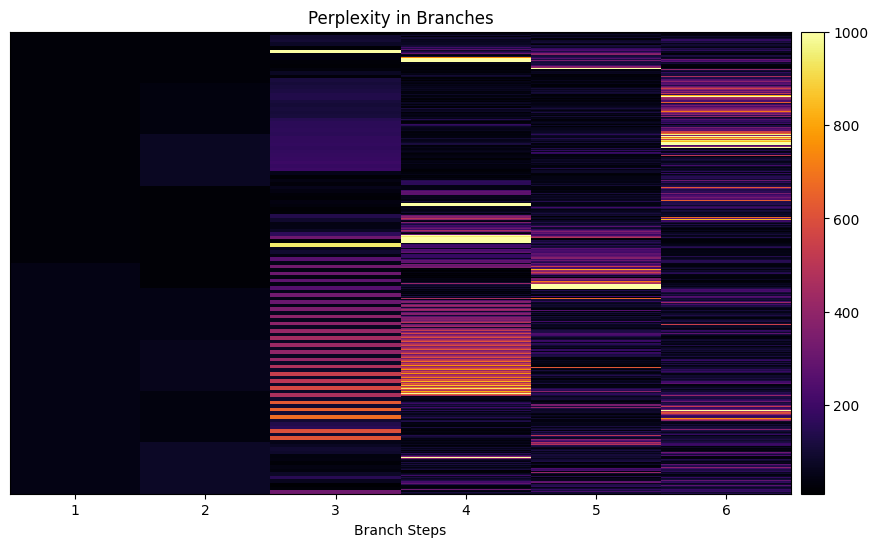

In [ ]:
# Create icicle visualizer
visualizer = IcicleDiagramVisualizer()

# Delete the first 12 characters of each sentence in sentences_test
text_data_test = [sentence[12:] for sentence in text_data]

for sentence in text_data_test:
    try:
        perplexity = calculate_perplexity(sentence)
    except Exception as e:
        perplexity = 0
        continue
    
    visualizer.insert(sentence, perplexity)

# Visualize the hierarchical icicle diagram
visualizer.visualize()

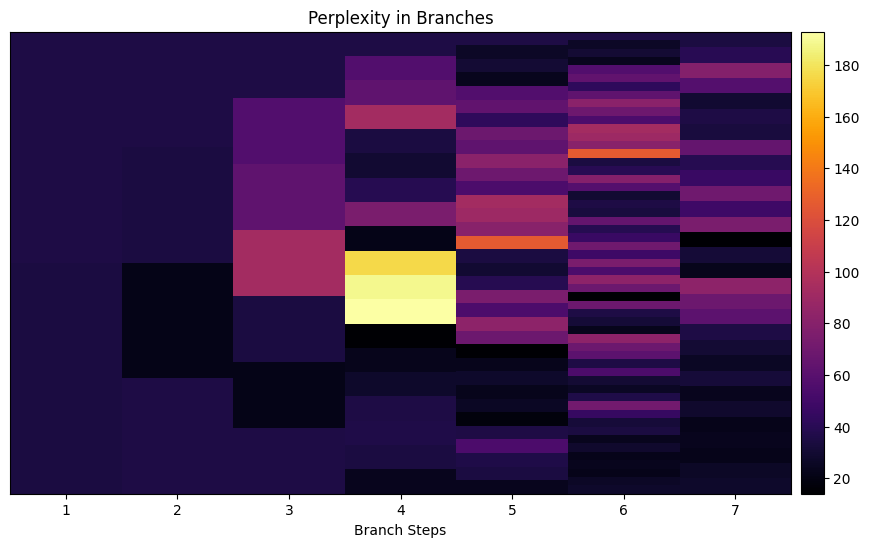

In [11]:
# Create icicle visualizer
visualizer = IcicleDiagramVisualizer()

# Delete the first 12 characters of each sentence in sentences_test
text_data_test = [sentence[12:] for sentence in v2_data]

for sentence in text_data_test:
    try:
        perplexity = calculate_perplexity(sentence)
    except Exception as e:
        perplexity = 0
        continue
    
    visualizer.insert(sentence, perplexity)

# Visualize the hierarchical icicle diagram
visualizer.visualize()

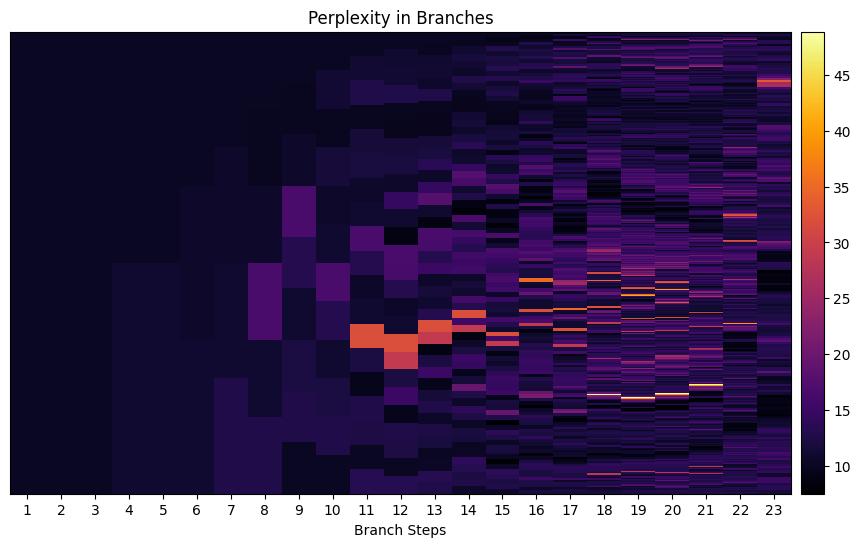

In [37]:
# Create icicle visualizer
visualizer = IcicleDiagramVisualizer()

# Delete the first 4 words of each sentence in sentences_test
text_data_test = [' '.join(sentence.split()[:]) for sentence in v3_data]

for sentence in text_data_test:
    try:
        perplexity = calculate_perplexity(sentence)
    except Exception as e:
        perplexity = 0
        continue
    
    visualizer.insert(sentence, perplexity)

# Visualize the hierarchical icicle diagram
visualizer.visualize()

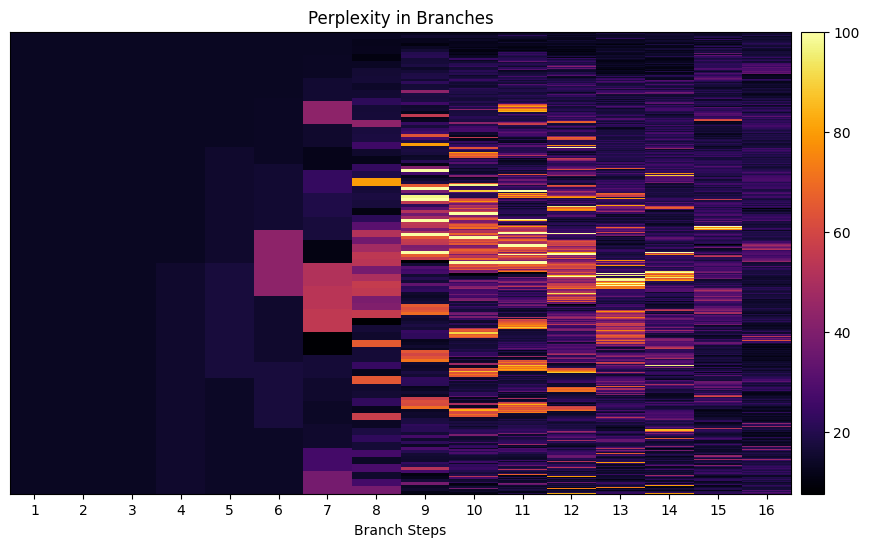

In [36]:
# Create icicle visualizer
visualizer = IcicleDiagramVisualizer()

# Delete the first 4 words of each sentence in sentences_test
text_data_test = [' '.join(sentence.split()[:]) for sentence in v4_data]

for sentence in text_data_test:
    try:
        perplexity = calculate_perplexity(sentence)
    except Exception as e:
        perplexity = 0
        continue
    
    visualizer.insert(sentence, perplexity)

# Visualize the hierarchical icicle diagram
visualizer.visualize()

In [3]:
class TrieNode:
    def __init__(self, token=""):
        self.token = token  # Word at this node
        self.children = {}  # Dictionary of child nodes
        self.perplexity = None  # Perplexity value

class PerplexityTrie:
    def __init__(self, calculate_perplexity):
        self.root = TrieNode()
        self.calculate_perplexity = calculate_perplexity  # External perplexity function

    def insert(self, sentence):
        """ Insert a sentence into the trie, computing perplexities at each step. """
        words = sentence.split()
        node = self.root
        accumulated_text = ""

        for word in words:
            accumulated_text += (word + " ")  # Build progressive text
            
            # Compute perplexity for this fragment
            perplexity = self.calculate_perplexity(accumulated_text.strip())

            # Add to trie if not already present
            if word not in node.children:
                node.children[word] = TrieNode(word)

            # Move to the next node
            node = node.children[word]
            node.perplexity = perplexity  # Store perplexity at this node

    def display(self, node=None, level=0):
        """ Recursively display the tree structure. """
        if node is None:
            node = self.root

        for word, child in node.children.items():
            print("  " * level + f"{word} (Perplexity: {child.perplexity:.2f})")
            self.display(child, level + 1)

# Example usage
def dummy_perplexity(text):
    """ Placeholder perplexity function (replace with real implementation). """
    return len(text) % 10  # Example: Modulo-based pseudo perplexity

# Create the Trie
trie = PerplexityTrie(dummy_perplexity)

for sentence in text_data:
    trie.insert(sentence)

# Display the tree with perplexities
trie.display()


Once (Perplexity: 4.00)
  upon (Perplexity: 9.00)
    a (Perplexity: 1.00)
      time, (Perplexity: 7.00)
        there (Perplexity: 3.00)
          was (Perplexity: 7.00)
            a (Perplexity: 9.00)
              little (Perplexity: 6.00)
              young (Perplexity: 5.00)
              girl (Perplexity: 4.00)
              man (Perplexity: 3.00)
              beautiful (Perplexity: 9.00)
            an (Perplexity: 0.00)
              old (Perplexity: 4.00)
              island (Perplexity: 7.00)
              idea (Perplexity: 5.00)
              artist (Perplexity: 7.00)
              American (Perplexity: 9.00)
            this (Perplexity: 2.00)
              little (Perplexity: 9.00)
              guy (Perplexity: 6.00)
              girl (Perplexity: 7.00)
              young (Perplexity: 8.00)
              thing (Perplexity: 8.00)
            the (Perplexity: 1.00)
              Internet (Perplexity: 0.00)
              idea (Perplexity: 6.00)
              internet 

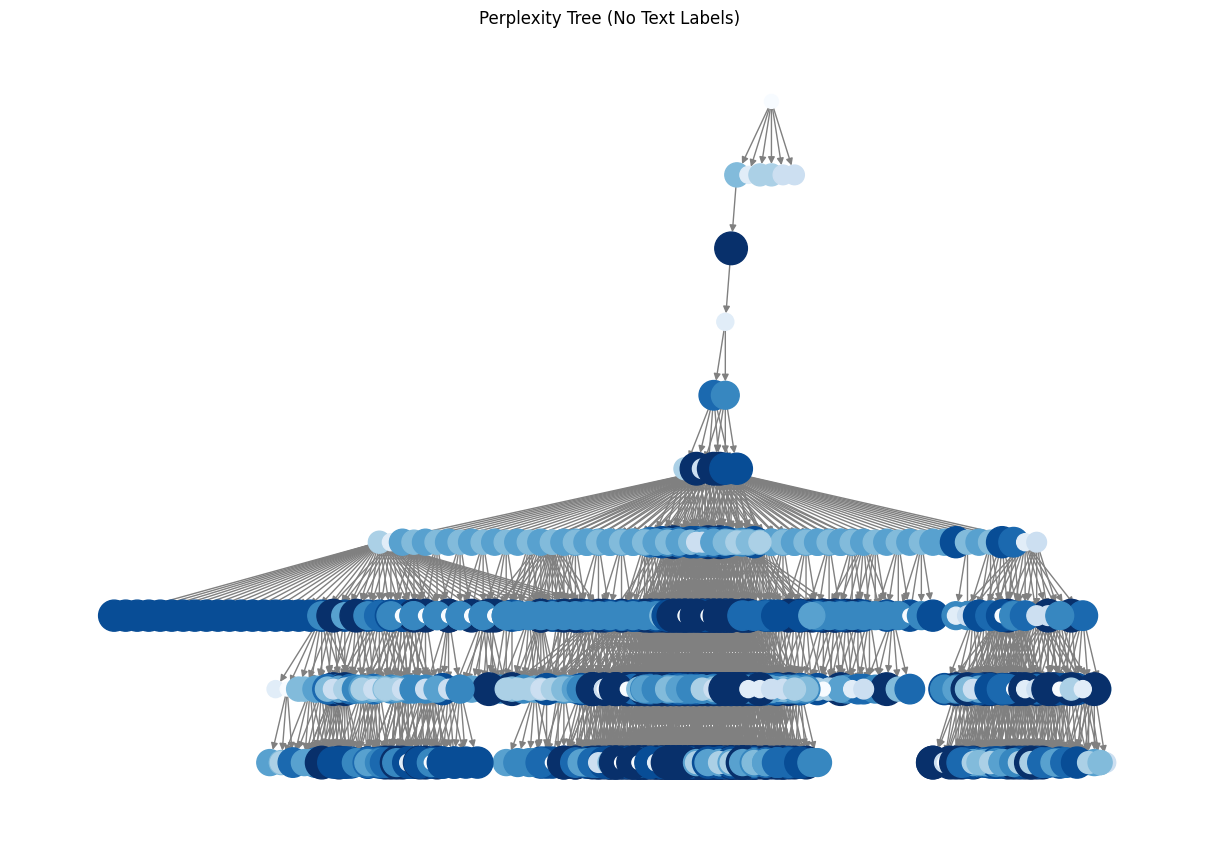

In [4]:
import networkx as nx
import matplotlib.pyplot as plt

class TrieNode:
    def __init__(self, token=""):
        self.token = token  # Word at this node
        self.children = {}  # Dictionary of child nodes
        self.perplexity = None  # Perplexity value

class PerplexityTrie:
    def __init__(self, calculate_perplexity):
        self.root = TrieNode()
        self.calculate_perplexity = calculate_perplexity  # Perplexity function

    def insert(self, sentence):
        """ Insert a sentence into the trie, computing perplexities at each step. """
        words = sentence.split()
        node = self.root
        accumulated_text = ""

        for word in words:
            accumulated_text += (word + " ")  # Build progressive text
            
            # Compute perplexity for this fragment
            perplexity = self.calculate_perplexity(accumulated_text.strip())

            # Add to trie if not already present
            if word not in node.children:
                node.children[word] = TrieNode(word)

            # Move to the next node
            node = node.children[word]
            node.perplexity = perplexity  # Store perplexity at this node

    def build_graph(self):
        """ Convert the Trie into a NetworkX graph. """
        G = nx.DiGraph()
        node_positions = {}  # Store node positions for layout
        perplexities = {}  # Store perplexities for visualization

        # Add root node explicitly
        G.add_node("ROOT", perplexity=0)
        node_positions["ROOT"] = (0, 0)
        perplexities["ROOT"] = 0

        def traverse(node, parent_name, depth=1, pos_x=0):
            """ Recursively traverse the trie to build the graph. """
            for i, (word, child) in enumerate(node.children.items()):
                child_name = f"{parent_name} {word}".strip()  # Unique node name

                # Add node with perplexity
                G.add_node(child_name, perplexity=child.perplexity)
                G.add_edge(parent_name, child_name)  # Connect parent-child

                # Compute and store node position
                node_positions[child_name] = (pos_x + i - len(node.children) / 2, -depth)
                perplexities[child_name] = child.perplexity

                # Recursively add children
                traverse(child, child_name, depth + 1, pos_x + i - len(node.children) / 2)

        traverse(self.root, "ROOT")  # Start from the root

        return G, node_positions, perplexities

    def visualize(self):
        """ Plot the Trie as a tree using NetworkX (without text labels). """
        G, pos, perplexities = self.build_graph()
        plt.figure(figsize=(12, 8))

        # Get perplexity values for coloring
        perplexity_values = [perplexities.get(node, 0) for node in G.nodes]

        # Draw the graph WITHOUT labels (just nodes and edges)
        nx.draw(G, pos, with_labels=False, node_size=[p * 50 + 100 for p in perplexity_values],
                node_color=perplexity_values, cmap=plt.cm.Blues, edge_color="gray")

        plt.title("Perplexity Tree (No Text Labels)")
        plt.show()


# Example perplexity function (replace with real model)
def dummy_perplexity(text):
    return len(text) % 10  # Mock perplexity for visualization

# Build the Trie and visualize it
trie = PerplexityTrie(dummy_perplexity)

for sentence in text_data:
    trie.insert(sentence)

# Visualize the tree without text
trie.visualize()


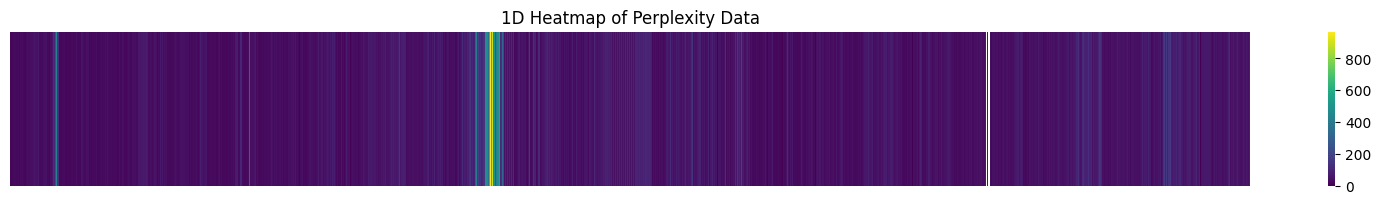

In [48]:
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

# Convert perplexity_data to a 2D array with a single row
perplexity_array = np.array(perplexity_data).reshape(1, -1)

# Create the heatmap
plt.figure(figsize=(20, 2))
sns.heatmap(perplexity_array, cmap="viridis", cbar=True, xticklabels=False, yticklabels=False)
plt.title("1D Heatmap of Perplexity Data")
plt.show()

In [50]:
calculate_perplexity(sentences_test[0])

16.239809036254883

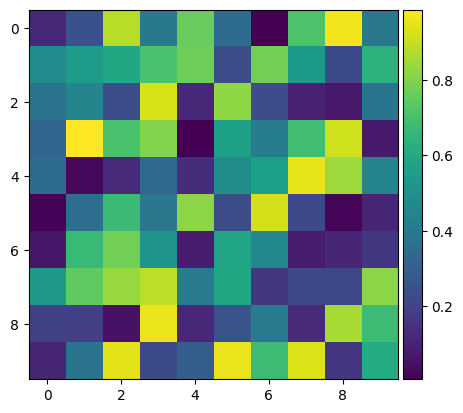

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Generate data
data = np.random.rand(10, 10)

fig, ax = plt.subplots()
cax = ax.imshow(data, cmap='viridis')

# Add colorbar with reduced padding
fig.colorbar(cax, ax=ax, pad=0.01)  # Decrease pad to reduce gap

plt.show()
